# Table-top-Telescope Experiment Code
- Designated code for the lecture by Dr. Shinyoung Lee (KASI) at 2026 KAO Winter School
- Revised by Jiwon Jang (SNU)
- Original code was developed by TA's of the 2024/2025 SNU NaturalScience Camp, including Donghwan Hyeon, Jiwon Jang, Wooseok Kang, Chanjin Lee, Wonhyeong Lee.  

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

from radio import set_root_dir, get_data_dir, get_log_dir
from radio.sdr import Exposure, expose_sdr
from radio.constants import N_FFT
from radio.io import load_data, load_spectra_from_list, load_source_header
from radio.utils import LSR_correction

# set the root directory location
set_root_dir(Path.cwd()) 

WindowsPath('C:/Programing/Astronomy/KAO/26 겨울학교/TTRT')

In [2]:
plt.rcParams['axes.unicode_minus'] =False
plt.rcParams['mathtext.fontset']='stix'
plt.rcParams['font.size']=18
plt.rcParams['legend.frameon']=False

# Check the Connection

from rtlsdr import RtlSdr
try:
    sdr = RtlSdr()
    print("SDR Device found!")
    sdr.close()
except:
    print("SDR Device not found. Please check your drivers.")

# Observation

In [9]:
gnd = Exposure(n_obs = 1, exposure_type = 'gnd')
gnd.run()

Exposure = gnd
------------------------------------------------------------
Data will be saved at [2026-01-10T07:41:33]


Iteration:   0%|          | 0/1 [00:00<?, ?it/s]

Exposure finished, 1 frame accumulated (t_exp = 0.09s)
------------------------------------------------------------


In [10]:
sky = Exposure(n_obs = 1, exposure_type = 'sky')
sky.run()

Exposure = sky
------------------------------------------------------------
Altitude [deg] = 0
Azimuthal angle [deg] = 0
(ra, dec) = 11h29m23.44493851s +55d36m57.73456991s
(l, b) = 144d47m23.42793625s 57d53m33.44567244s
Data will be saved at [2026-01-10T07:41:36] with l=145, b=58


Iteration:   0%|          | 0/1 [00:00<?, ?it/s]

Exposure finished, 1 frame accumulated (t_exp = 0.09s)
------------------------------------------------------------


# Load Data

### Demo data (optional)

In [4]:
demo_dir = get_data_dir() / 'demo_data'
sky_list = list(demo_dir.glob("*sky*.csv"))
gnd_list = list(demo_dir.glob("*ground*.csv"))
print(f'Sky    = {len(sky_list)} frame loaded')
print(f'Ground = {len(gnd_list)} frame loaded')

Sky    = 40 frame loaded
Ground = 30 frame loaded


In [17]:
Ps = np.zeros((2, N_FFT))
for k, flist in enumerate([sky_list, gnd_list]):
    power_list = []
    for i, f in enumerate(flist):
        data = load_data(f)
        power_list.append(data["power"])
    freq = np.array(data["frequency"])
    powers = np.array(power_list)
    Ps[k]  = np.median(powers, axis = 0)

P_src, P_amb = Ps

### Load Data

In [13]:
log_path = list(get_log_dir().glob('log*.csv'))[0]
log = load_data(log_path)

In [14]:
# load ground spectra
gnd_spectra, gnd_missing = load_spectra_from_list(log, exposure_type = 'gnd')
gnd_flist = list(gnd_spectra.keys())
gnd_fname = gnd_flist[0]
gnd_hdr = load_source_header(log, gnd_fname)

# load sky (source) spectra
src_spectra, src_missing = load_spectra_from_list(log, exposure_type = 'sky', alt = 0, az = 30)
src_flist = list(src_spectra.keys())
src_fname = src_flist[0]
src_hdr = load_source_header(log, src_fname)

freq =  np.array(src_spectra[src_fname]['frequency'])
P_src =  np.array(src_spectra[src_fname]['power'])
P_amb =  np.array(gnd_spectra[gnd_fname]['power'])

Data directory = C:\Programing\Astronomy\KAO\26 겨울학교\TTRT\data
------ loaded -------
2026-01-10T06-12-43_0.1s_gnd.csv
2026-01-10T07-41-33_0.1s_gnd.csv

Data directory = C:\Programing\Astronomy\KAO\26 겨울학교\TTRT\data
------ loaded -------
2026-01-10T06-13-21_171_20_0.1s_sky.csv



# Data Reduction

## 1. Flux Calibration

We start by writing
$$
P_{\mathrm{src}} = G (T_{\mathrm{src}} + T_{\mathrm{sys}}) \\
$$
$$
P_{\mathrm{amb}} = G (T_{\mathrm{amb}} + T_{\mathrm{sys}}) \\
$$
$$
P_{\mathrm{sky}} = G (0 + T_{\mathrm{sys}}) \\
$$
(spectral dependence simplified).

In our case, we couldn't take $P_{sky}$!


We use 
$$
Y = P_{\mathrm{amb}}/P_{\mathrm{sky}} \simeq P_{\mathrm{amb}}/P_{\mathrm{src}} \\
$$
$$
P_{\mathrm{sky}} \simeq \dfrac{P_{\mathrm{amb}}}{Y} \\
$$

Solving for $T_{sys}$,

$$
T_{\mathrm{sys}} = \frac{T_{amb}}{Y-1}
$$
<!-- $$
T_{\mathrm{sys}} = \frac{T_{H} - Y\times T_{L}}{Y-1}
$$ -->


, which leads to

$$
T_{\mathrm{src}} \simeq \dfrac{P_{\mathrm{src}} - P_{\mathrm{sky}}}{P_{sky}} T_{sys} = \dfrac{P_{\mathrm{src}} - P_{\mathrm{sky}}}{P_{amb} - P_{sky}} T_{amb} \\
$$

<!-- T_{sky} -->

In [6]:
T_sky = 20  # K
T_amb = 300  # 273.15 K + 30 K

# Y-factor
Y = np.median(P_amb / P_src)
P_sky = P_amb / Y

# antenna temperature
T_src = (P_src - P_sky) / (P_amb - P_sky) * T_amb

### Plot

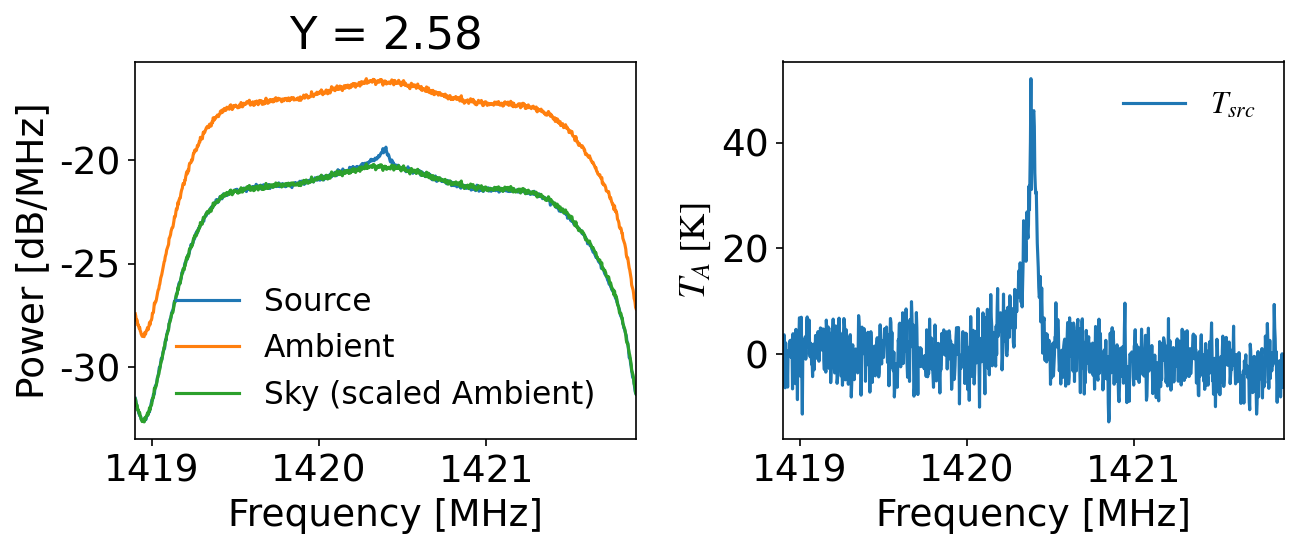

In [7]:
fig, ax = plt.subplots(1,2,figsize = (9,4), dpi = 150)
# Fig 1: Y-factor calculation
ax[0].set_title(f"Y = {Y:.2f}")
ax[0].plot(freq, 10 * np.log10(P_src), label="Source")
ax[0].plot(freq, 10 * np.log10(P_amb), label="Ambient")
ax[0].plot(freq, 10 * np.log10(P_sky), label="Sky (scaled Ambient)")
ax[0].set_ylabel("Power [dB/MHz]")
ax[0].set_xlabel("Frequency [MHz]")
ax[0].set_xlim(freq[0], freq[-1])
ax[0].legend(fontsize = 15)

# Fig 2: Antenna Temperature
ax[1].plot(freq, T_src, label=r"$T_{src}$")
ax[1].set_xlim(freq[0], freq[-1])
ax[1].set_ylabel(r"$T_A\rm\;[K]$")
ax[1].set_xlabel("Frequency [MHz]")
ax[1].legend(fontsize = 15)
plt.tight_layout()
plt.show()

## 2. Frequency $\rightarrow$ LSR velocity

### Frequency to Velocity

We convert the frequency to line-of-sight velocity to see the kinematics of the HI gas clouds.

### LSR correction
- Correcting the orbitatl motion of the Earth around the sun.
- The solar system also moves at 20.0 km/s toward l=56°, b=23° with respect to the LSR. Decomposed, it corresponds to [U, V, W] = [10, 5, 7]

In [18]:
f0 = 1420.40575  # rest frame frequency of HI
c = 299792.458  # lightspeed in [km/s]

# convert frequency to radial velocity
V_r = - c * (freq - f0) / freq

# LSR velocity
helio_corr, peculiar_corr = LSR_correction(l = src_hdr.l, b = src_hdr.b , obstime = src_hdr.obstime)
V_corr = helio_corr + peculiar_corr
print(f"Heliocentric correction (obs → helio): {helio_corr:.2f} km/s")
print(f"Solar-motion correction (helio → LSR): {peculiar_corr:.2f} km/s")
print(f"Total LSR correction (obs → LSR): {V_corr:.2f} km/s")
V_LSR = V_r + V_corr

Heliocentric correction (obs → helio): -3.93 km/s
Solar-motion correction (helio → LSR): 10.35 km/s
Total LSR correction (obs → LSR): 6.42 km/s


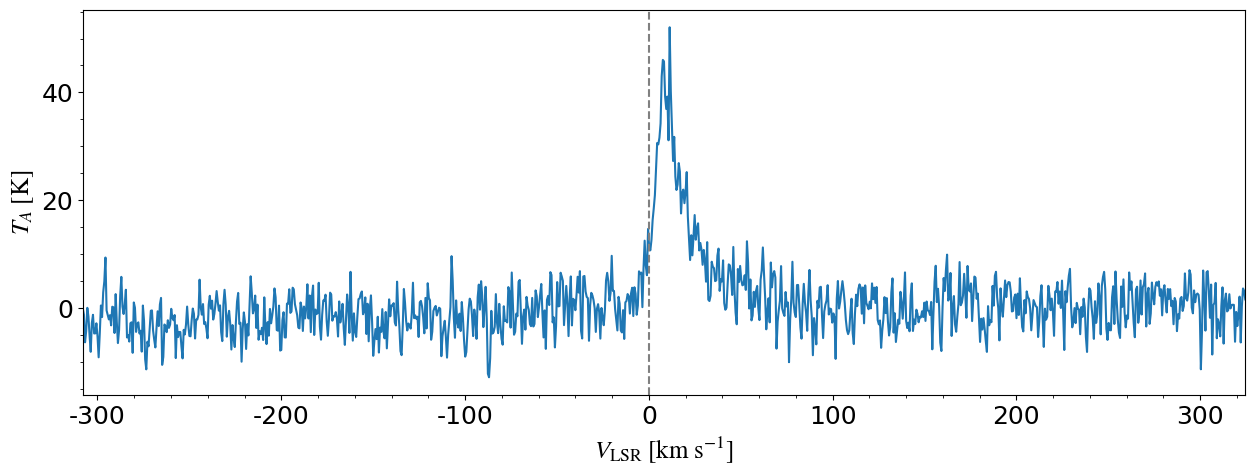

In [19]:
plt.figure(figsize=(15, 5))
plt.plot(V_LSR, T_src, color="C0")
plt.axvline(0, ls="dashed", color="gray")
plt.xlim(np.min(V_LSR), np.max(V_LSR))
plt.xlabel(r"$ V_{\rm LSR}\rm\;[km\ s^{-1}]$")
plt.ylabel(r"$T_A\rm\;[K]$")
plt.minorticks_on()
plt.show()